In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

import SimpleITK as sitk
import ipywidgets as widgets
from ipywidgets import interact
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [3]:
download_base = Path("./data/abc_atlas")

abc_cache = AbcProjectCache.from_cache_dir(download_base)

download_base.mkdir(parents=True, exist_ok=True)

In [4]:
template_file = abc_cache.get_file_path(
    directory="Allen-CCF-2020",
    file_name="average_template_25"
)

annotation_file = abc_cache.get_file_path(
    directory="Allen-CCF-2020",
    file_name="annotation_25"
)

template_image = sitk.ReadImage(template_file)
annotation_image = sitk.ReadImage(annotation_file)

template = sitk.GetArrayFromImage(template_image)
annotation = sitk.GetArrayFromImage(annotation_image)

average_template_25.nii.gz: 100%|██████████| 33.0M/33.0M [00:02<00:00, 11.2MMB/s]
annotation_25.nii.gz: 100%|██████████| 3.63M/3.63M [00:00<00:00, 7.91MMB/s]


In [5]:
parcellation_annotation = abc_cache.get_metadata_dataframe(
    directory="Allen-CCF-2020",
    file_name="parcellation_to_parcellation_term_membership"
)

parcellation_to_parcellation_term_membership.csv: 100%|██████████| 680k/680k [00:00<00:00, 3.83MMB/s]


In [10]:
parcellation_annotation[
    parcellation_annotation["parcellation_term_acronym"] == "VISp"
]

,parcellation_label,parcellation_term_label,parcellation_term_set_label,parcellation_index,voxel_count,volume_mm3,color_hex_triplet,red,green,blue,parcellation_term_name,parcellation_term_acronym,parcellation_term_set_name,term_set_order,term_order,parent_term_label
589,AllenCCF-Annotation-2020-593,AllenCCF-Ontology-2017-385,AllenCCF-Ontology-2017-STRU,583,1263430,1.263430,#08858C,8,133,140,Primary visual area,VISp,structure,3,21,AllenCCF-Ontology-2017-315
594,AllenCCF-Annotation-2020-821,AllenCCF-Ontology-2017-385,AllenCCF-Ontology-2017-STRU,811,1999040,1.999040,#08858C,8,133,140,Primary visual area,VISp,structure,3,21,AllenCCF-Ontology-2017-315
599,AllenCCF-Annotation-2020-721,AllenCCF-Ontology-2017-385,AllenCCF-Ontology-2017-STRU,711,1023640,1.023640,#08858C,8,133,140,Primary visual area,VISp,structure,3,21,AllenCCF-Ontology-2017-315
604,AllenCCF-Annotation-2020-778,AllenCCF-Ontology-2017-385,AllenCCF-Ontology-2017-STRU,768,1552688,1.552688,#08858C,8,133,140,Primary visual area,VISp,structure,3,21,AllenCCF-Ontology-2017-315
609,AllenCCF-Annotation-2020-33,AllenCCF-Ontology-2017-385,AllenCCF-Ontology-2017-STRU,29,1070864,1.070864,#08858C,8,133,140,Primary visual area,VISp,structure,3,21,AllenCCF-Ontology-2017-315
614,AllenCCF-Annotation-2020-305,AllenCCF-Ontology-2017-385,AllenCCF-Ontology-2017-STRU,295,164472,0.164472,#08858C,8,133,140,Primary visual area,VISp,structure,3,21,AllenCCF-Ontology-2017-315


In [44]:
roi_colors = {
    "VISp": "red",
    "STRd": "blue",
    "STRv": "cyan",
    "MOs": "orange",
    "MOp": "purple",
    "TH": "yellow",
}

In [17]:
def get_roi_indices(acronym):
    
    rows = parcellation_annotation[
        parcellation_annotation["parcellation_term_acronym"] == acronym
    ]
    
    if len(rows) == 0:
        print(f"Warning: ROI '{acronym}' not found.")
        return []
    
    return rows["parcellation_index"].unique()

In [18]:
get_roi_indices("VISp")

array([583, 811, 711, 768,  29, 295])

In [19]:
def create_color_volume(annotation, roi_colors):
    
    rgba = np.zeros(annotation.shape + (4,), dtype=np.float32)

    for acronym, color in roi_colors.items():
        
        indices = get_roi_indices(acronym)
        
        mask = np.isin(annotation, indices)
        
        rgba[mask] = to_rgba(color)

    return rgba

In [45]:
colored_rois = create_color_volume(annotation, roi_colors)

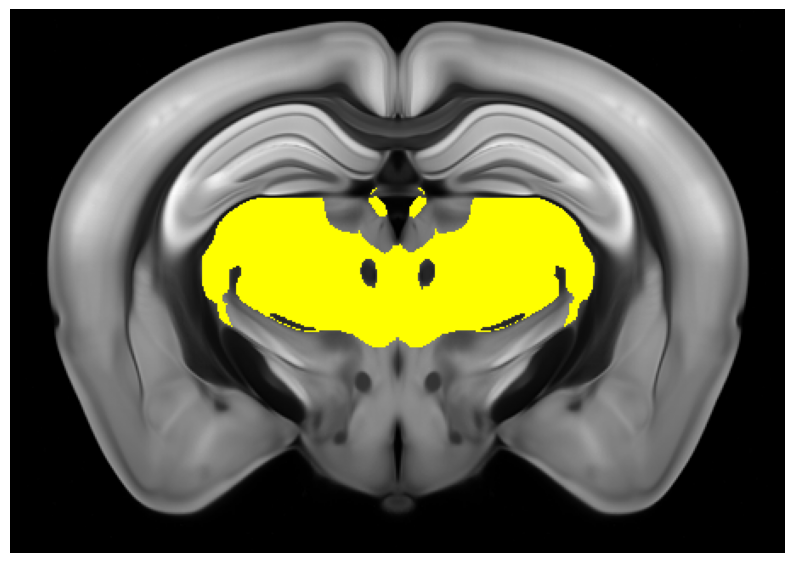

In [23]:
slice_index = 300

brain_slice = np.transpose(template[:, :, slice_index])
roi_slice = np.transpose(colored_rois[:, :, slice_index], (1, 0, 2))

plt.figure(figsize=(10, 8))

plt.imshow(brain_slice, cmap="gray")
plt.imshow(roi_slice)

plt.axis("off")
plt.show()

In [25]:
def show_slice(volume, slice_index, axis=0, cmap="gray", title=None):
    """
    axis=0,1,2 para elegir en qué dimensión cortar
    """
    if axis == 0:
        img = volume[slice_index, :, :]
    elif axis == 1:
        img = volume[:, slice_index, :]
    elif axis == 2:
        img = volume[:, :, slice_index]
    else:
        raise ValueError("axis must be 0, 1, or 2")

    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap=cmap)
    plt.axis("off")
    
    if title is None:
        title = f"axis={axis}, slice={slice_index}"
    plt.title(title)
    plt.show()

In [26]:
print(template.shape)

(456, 320, 528)


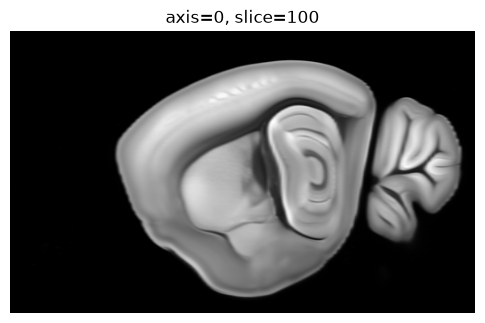

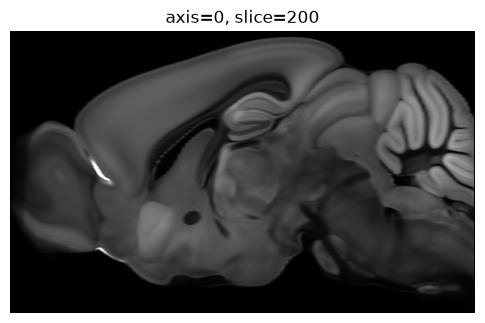

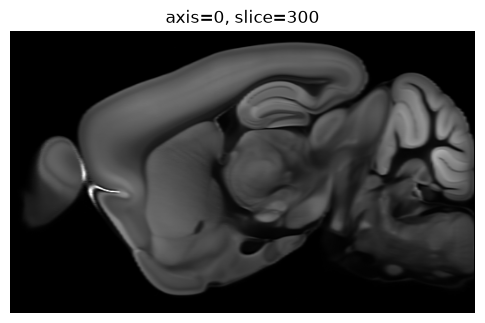

In [27]:
show_slice(template, slice_index=100, axis=0)
show_slice(template, slice_index=200, axis=0)
show_slice(template, slice_index=300, axis=0)

In [43]:
def show_overlay_slice(template, colored_rois, slice_index, axis=0):
    if axis == 0:
        base = template[slice_index, :, :]
        overlay = colored_rois[slice_index, :, :, :]
        
    elif axis == 1:
        base = template[:, slice_index, :]
        overlay = colored_rois[:, slice_index, :, :]
        
    elif axis == 2:
        base = template[:, :, slice_index]
        overlay = colored_rois[:, :, slice_index, :]
        
        # rota 90 grados
        base = np.rot90(base, k=3)
        overlay = np.rot90(overlay, k=3)

    else:
        raise ValueError("axis must be 0, 1, or 2")

    plt.figure(figsize=(6, 6))
    plt.imshow(base, cmap="gray")
    plt.imshow(overlay)
    plt.title(f"Slice {slice_index} | axis={axis}")
    plt.axis("off")
    plt.show()

In [42]:
@interact(slice_index=widgets.IntSlider(min=0, max=template.shape[0]-1, step=1, value=100))
def browse_overlay(slice_index):
    show_overlay_slice(template, colored_rois, slice_index=slice_index, axis=2)

interactive(children=(IntSlider(value=100, description='slice_index', max=455), Output()), _dom_classes=('widg…

In [46]:
def find_roi(acronym):
    # Search full ontology
    full = parcellation_term[
        parcellation_term["acronym"].str.lower() == acronym.lower()
    ]

    # Search terms actually mapped to voxels
    mapped = parcellation_annotation[
        parcellation_annotation["parcellation_term_acronym"].str.lower()
        == acronym.lower()
    ]

    print(f"ROI: {acronym}")
    print(f"Found in full ontology: {len(full) > 0}")
    print(f"Found in mapped parcellations: {len(mapped) > 0}")

    if len(full):
        display(full[["acronym", "name", "identifier", "parent_identifier"]])

    if len(mapped):
        print(
            "Hierarchy level(s):",
            mapped["parcellation_term_set_name"].unique()
        )
        print(
            "Number of parcellations:",
            mapped["parcellation_index"].nunique()
        )